# 第071课 K均值与原型学习

本Notebook先复算数值，再解释图像。请从头执行全部单元。生成标签不参与拟合；源CSV可按固定种子重建。

In [1]:
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
import numpy as np
from pathlib import Path
from IPython.display import display, Image
from common import ROOT, load_data
from experiment import run
report = run()
print('Unit', report['unit'], 'report recomputed')

Unit 071 report recomputed


## 数据与边界
数据检查同时比较散列与生成字节。以下只展示行数，不把生成分组作为算法输入。

In [2]:
data = load_data()
for name, values in data.items():
    print(name, len(values['id']), 'rows')

restarts 200 rows
scale 240 rows
rings 360 rows


## 五点手算
分别核对固定分配更新和最近中心重分配。目标应经过114、65、45.5、31/6。

In [3]:
from kmeans import fit
hand = fit([[0],[2],[3],[10],[11]], 2, init=[[0],[3]], n_init=1)
for row in hand['history']:
    print(row['iteration'], row['before'], row['after_update'], row['after_assign'])
print('Independent final objective:', 31/6)

1 114.0 65.0 45.5
2 45.5 5.166666666666667 5.166666666666667
3 5.166666666666667 5.166666666666667 5.166666666666667
Independent final objective: 5.166666666666667


## 重启的分布
一次好结果不证明每次都好，最优候选也不证明全局最优。

In [4]:
for method in ['random', 'kmeans_plus_plus']:
    values = report[method]['restart_inertias']
    print(method, 'min', min(values), 'max', max(values), 'runs', len(values))

random min 208.5877389082513 max 1817.5717308189405 runs 40
kmeans_plus_plus min 208.5877389082513 max 1817.5717308189405 runs 40


## 退化输入
空簇可恢复，但重复位置不能凭空创造不同群体。

In [5]:
print('Rescued empty-cluster centers:', report['empty']['centers'])
print('All-identical data effective_k:', report['duplicate']['effective_k'])
print('All-identical inertia:', report['duplicate']['inertia'])

Rescued empty-cluster centers: [[0.0], [1.0], [10.0]]
All-identical data effective_k: 1
All-identical inertia: 0.0


## 从本次结果重新绘图
图像由当前计算报告产生并嵌入输出，离线打开Notebook仍可看见。

01_manual_rounds.png


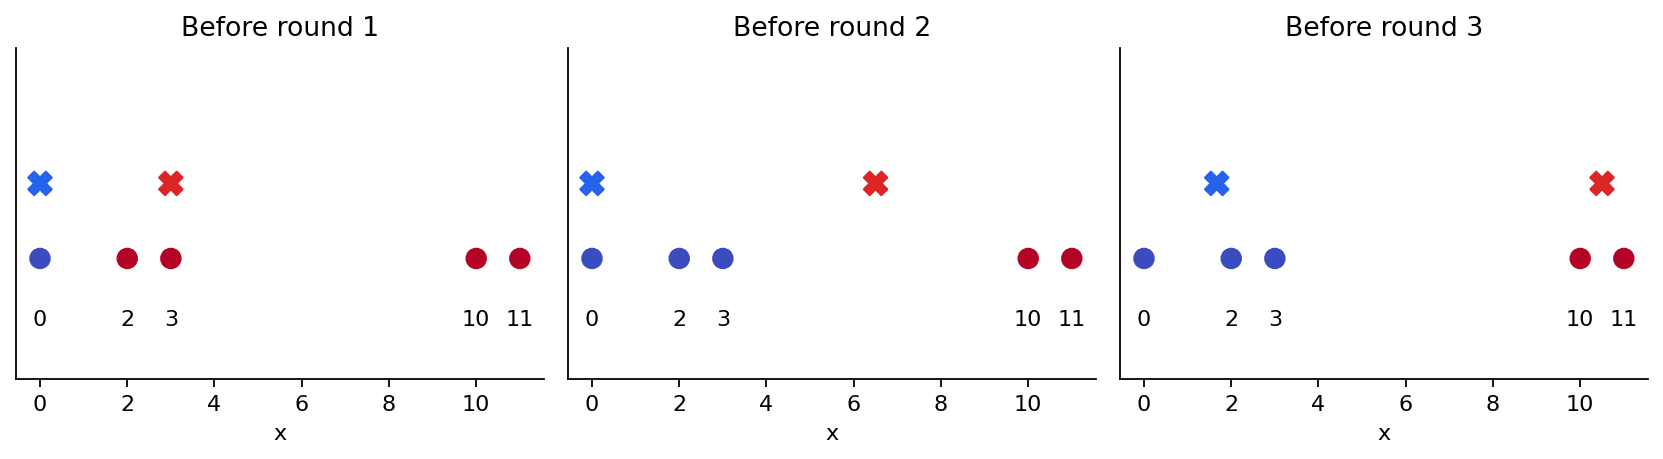

02_objective_restarts.png


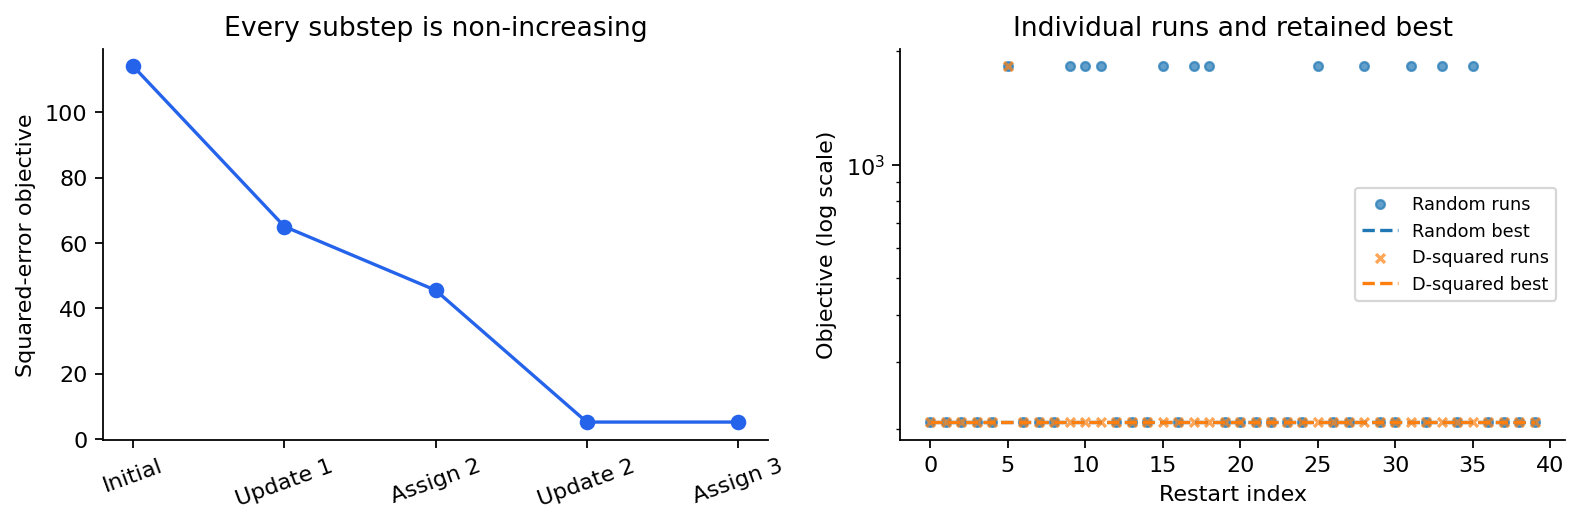

03_local_and_shape.png


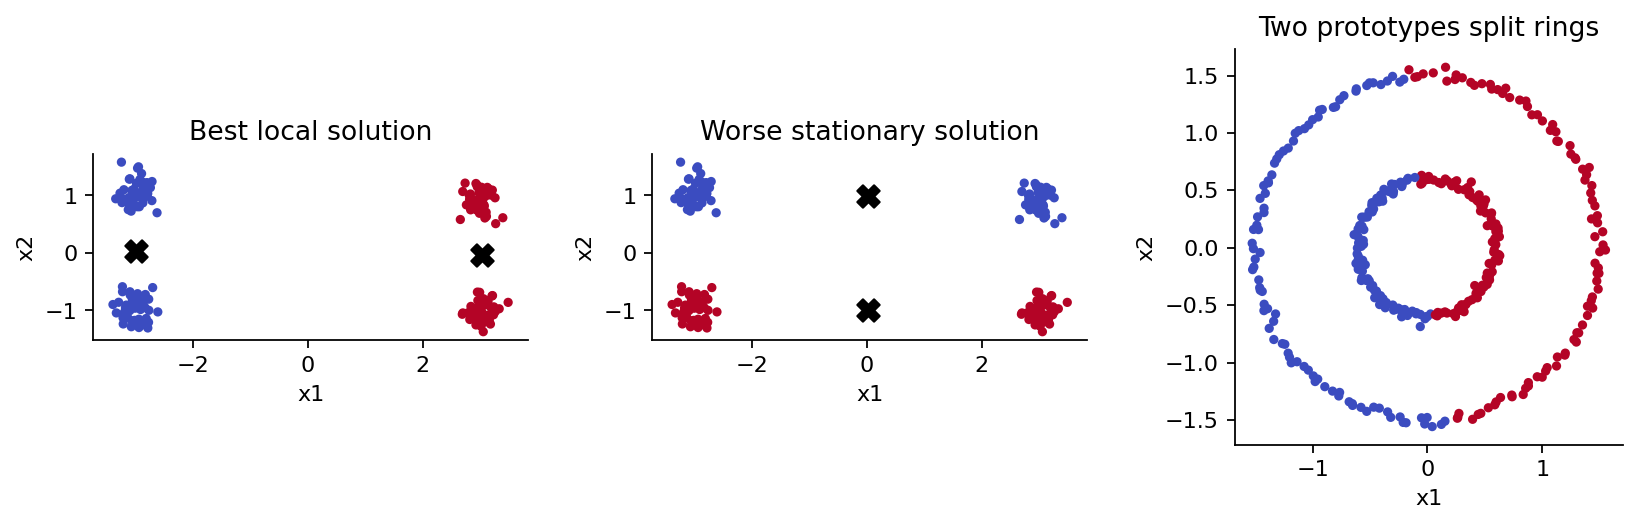

04_scale_changes.png


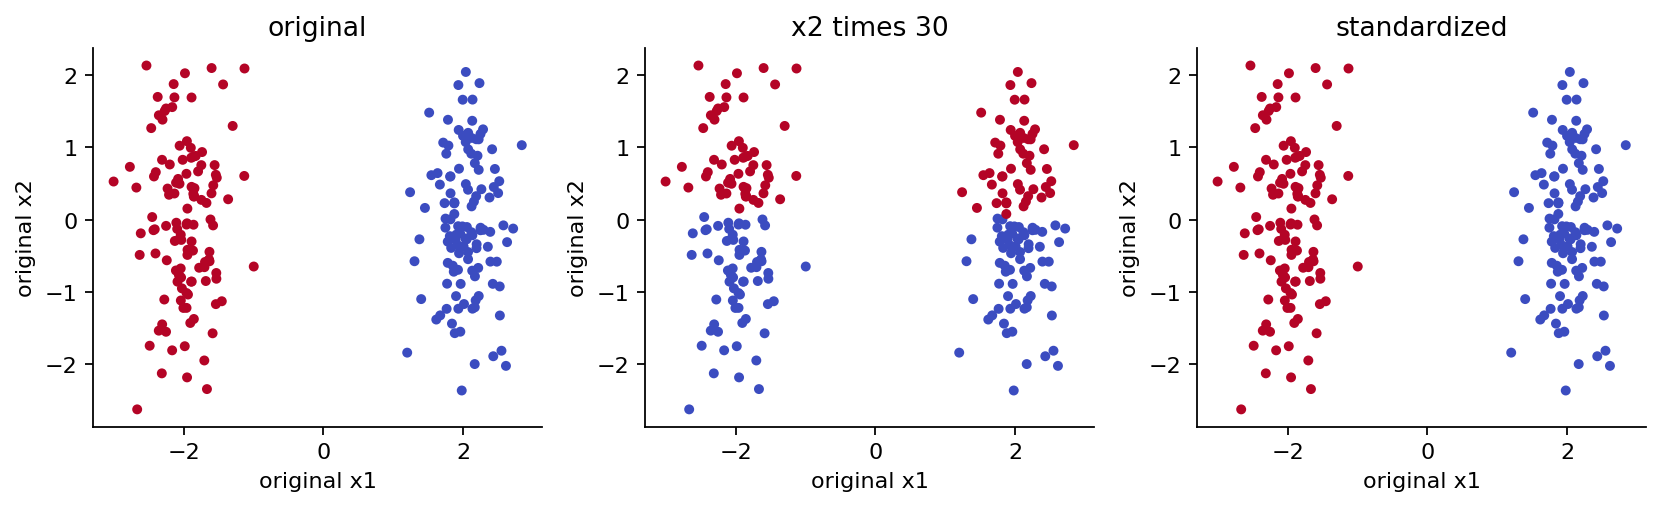

05_k_and_empty.png


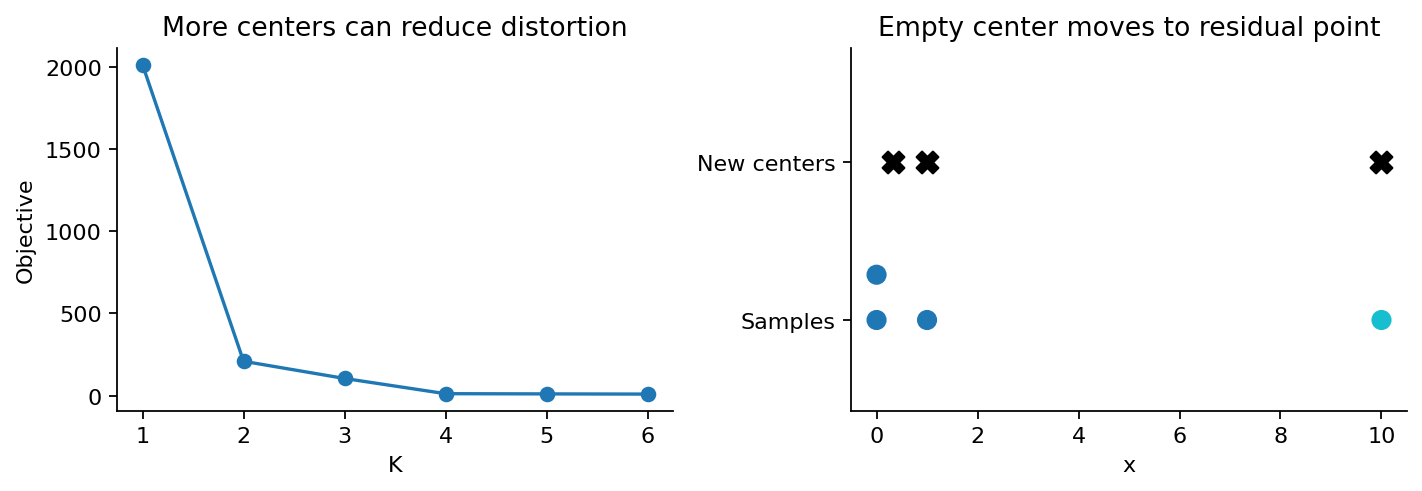

In [6]:
from plots import make
figure_dir = ROOT / 'outputs/notebook-figures'
make(report, figure_dir)
for filename in sorted(figure_dir.glob('*.png')):
    print(filename.name)
    display(Image(filename=str(filename)))

## 独立验收
显式检查在Python优化模式下也不会消失；命令行另提供-O运行报告。

In [7]:
from test_experiment import CHECKS, common_checks, specific
CHECKS.clear()
verified_data = common_checks(report)
specific(report, verified_data)
print('Passed explicit checks:', len(CHECKS))

Passed explicit checks: 113


## 结论
把结果写成带条件的陈述：说明距离、参数、失败机制和未验证之处。更多解释与练习答案见同目录讲义、实验和答案文档。